# GRASP sensor selection for the ANN detector

This notebook demonstrates GRASP with path relinking and applies it to select the chlorine-sensor subset for the **weak-contamination dataset only**. The production detector keeps the chlorine regressor fixed at `(128, 64, 32)` and the event classifier fixed at `(32,)`.

GRASP may select at most one third of the available chlorine sensors. Candidate subsets are ranked using validation balanced accuracy; the held-out test scenarios are evaluated only after selection.


In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parents[1]
sys.path.insert(0, str(project_root))

from src.event_detection_pipeline.grasp import (
    GraspConfig,
    grasp_architecture_search,
    parameter_count,
)

# GRASP implementation

- `construct()` starts at a small ANN and doubles one selected layer. Candidate moves form a restricted candidate list (RCL), from which one is chosen randomly.
- Feasibility means `metric >= baseline_metric - metric_tolerance`; construction therefore stops growing when it matches the ANN without GRASP.
- `local_search()` reduces layer widths while preserving feasibility.
- `path_relink()` moves one layer at a time from the new solution toward a randomly selected elite solution.
- `update_elite()` retains the smallest feasible architectures, breaking ties by better metric.
- The returned solution is the feasible elite member with the fewest trainable parameters.

In [4]:
import numpy as np
import torch

from src.event_detection_pipeline.model import (
    predict_event_probability,
    select_device,
    train_event_classifier,
)
from src.event_detection_pipeline.pipeline import _calibrate_balanced_accuracy_threshold

rng = np.random.default_rng(42)
X = rng.normal(size=(1200, 12)).astype(np.float32)
signal = 1.8 * X[:, 0] - X[:, 1] + 0.7 * X[:, 2] * X[:, 3]
y = (signal > np.quantile(signal, 0.88)).astype(np.float32)
order = rng.permutation(len(X))
train_index, validation_index = order[:900], order[900:]
X_train, y_train = X[train_index], y[train_index]
X_validation, y_validation = X[validation_index], y[validation_index]
device = select_device()

trained_models = {}

def ann_evaluator(hidden_sizes):
    # Stable per-architecture seed makes cached comparisons reproducible.
    seed = 42 + sum((i + 1) * width for i, width in enumerate(hidden_sizes))
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = train_event_classifier(
        X_train, y_train, X_validation, y_validation, device,
        hidden_sizes=hidden_sizes,
        epochs=30,
        patience=5,
        batch_size=128,
    )
    probability = predict_event_probability(model, X_validation, device)
    threshold = _calibrate_balanced_accuracy_threshold(
        y_validation.astype(bool), probability
    )
    alarms = probability >= threshold
    flags = y_validation.astype(bool)
    sensitivity = alarms[flags].mean()
    specificity = (~alarms[~flags]).mean()
    trained_models[tuple(hidden_sizes)] = model
    return float(0.5 * (sensitivity + specificity))

In [5]:
# This cell trains several networks and can take a few minutes.
ann_result = grasp_architecture_search(
    ann_evaluator,
    input_dim=X_train.shape[1],
    baseline_hidden_sizes=(128, 64),
    config=GraspConfig(
        iterations=4,
        max_evaluations=20,
        elite_size=4,
        relink_solutions=1,
        min_hidden_size=4,
        # A small tolerance is often sensible because ANN training is noisy.
        metric_tolerance=0.005,
        random_seed=42,
    ),
)
ann_result

GraspResult(hidden_sizes=(32, 63), metric=0.9124513618677043, baseline_metric=0.9105510813501041, parameter_count=2559, evaluations=20, elite=(ArchitectureScore(hidden_sizes=(32, 63), metric=0.9124513618677043, parameter_count=2559, feasible=True), ArchitectureScore(hidden_sizes=(128, 64), metric=0.9105510813501041, parameter_count=9985, feasible=True)))

## GRASP sensor search: weak versus strong contamination

The same protocol is run independently on weak- and strong-contamination files. The regressor `(128, 64, 32)` and classifier `(32,)` remain fixed; GRASP changes only the chlorine-sensor subset, with a hard cap of one third of the available sensors.

Fitness is validation balanced accuracy. Recall, specificity and false-alarm rate (FAR) are also recorded for every evaluated subset so we can test whether fewer sensors systematically increase false positives. The outer test scenarios remain untouched until selection is complete.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection import (
    SensorGraspConfig,
    aggregate_evaluation_summary,
    build_detector,
    collect_default_data_paths,
    collect_strong_contamination_paths,
    grasp_sensor_subset_search,
    split_train_test,
)
from src.event_detection_pipeline.data import split_file
from src.event_detection_pipeline.evaluation import (
    plot_chlorine_prediction_quality,
    plot_precision_recall_curve,
    plot_roc_curve_event_detection,
)
from src.event_detection_pipeline.model_io import save_detector

REGRESSION_HIDDEN_SIZES = (128, 64, 32)
CLASSIFIER_HIDDEN_SIZES = (32,)
HISTORY = 48
EPOCHS = 60
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
DROPOUT = 0.0
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 8
MAX_VALIDATION_FALSE_ALARM_RATE = 0.2
RANDOM_SEED = 42


In [7]:
def train_fixed_detector(fit_paths, sensor_indices):
    return build_detector(
        fit_paths,
        history=HISTORY,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        hidden_sizes=REGRESSION_HIDDEN_SIZES,
        dropout=DROPOUT,
        weight_decay=WEIGHT_DECAY,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        max_validation_false_alarm_rate=MAX_VALIDATION_FALSE_ALARM_RATE,
        classifier_hidden_sizes=CLASSIFIER_HIDDEN_SIZES,
        chlorine_sensor_indices=sensor_indices,
        grasp_config=None,
        random_seed=RANDOM_SEED,
    )

def run_sensor_experiment(dataset_name, data_paths):
    train_paths, test_paths = split_train_test(data_paths)
    sensor_fit_paths, sensor_validation_paths = split_train_test(train_paths)
    _, sensor_groups = split_file(sensor_fit_paths[0], history=HISTORY)
    sensor_count = len(sensor_groups.chlorine)
    max_sensors = max(1, sensor_count // 3)
    evaluation_records = []

    print(f"\n{dataset_name.upper()} CONTAMINATION")
    print(f"Outer train/test: {len(train_paths)}/{len(test_paths)} files")
    print(f"Search fit/validation: {len(sensor_fit_paths)}/{len(sensor_validation_paths)} files")
    print(f"Sensor budget: at most {max_sensors} of {sensor_count}")

    def evaluate_subset(sensor_indices, label="GRASP candidate"):
        detector = train_fixed_detector(sensor_fit_paths, sensor_indices)
        validation_results = [detector.detect(path) for path in sensor_validation_paths]
        metrics = aggregate_evaluation_summary(validation_results)
        nodes = [sensor_groups.chlorine_nodes[index] for index in sensor_indices]
        record = {
            "dataset": dataset_name,
            "label": label,
            "subset": tuple(sensor_indices),
            "nodes": tuple(nodes),
            "sensor_count": len(sensor_indices),
            **metrics,
        }
        evaluation_records.append(record)
        print(
            f"subset={tuple(sensor_indices)}, nodes={nodes}, "
            f"BA={metrics['balanced_accuracy']:.4f}, "
            f"recall={metrics['recall']:.4f}, "
            f"specificity={metrics['specificity']:.4f}, "
            f"FAR={metrics['false_alarm_rate']:.4f}"
        )
        return metrics["balanced_accuracy"]


    search_result = grasp_sensor_subset_search(
        evaluate_subset,
        sensor_count=sensor_count,
        max_sensors=max_sensors,
        config=SensorGraspConfig(
            iterations=8,
            max_evaluations=40,
            elite_size=6,
            relink_solutions=2,
            alpha=0.3,
            random_seed=RANDOM_SEED,
        ),
    )
    selected_indices = list(search_result.sensor_indices)
    selected_nodes = [sensor_groups.chlorine_nodes[index] for index in selected_indices]
    assert 1 <= len(selected_indices) <= max_sensors

    # Retrain the GRASP-selected subset on the complete outer training set.
    selected_detector = train_fixed_detector(train_paths, selected_indices)
    save_detector(
        selected_detector,
        directory=str(
            project_root / "results" / "ANN"
            / f"grasp_sensor_{dataset_name}_128-64-32_classifier-32"
        ),
    )
    return {
        "name": dataset_name,
        "groups": sensor_groups,
        "max_sensors": max_sensors,
        "search_result": search_result,
        "records": pd.DataFrame(evaluation_records),
        "selected_indices": selected_indices,
        "selected_nodes": selected_nodes,
        "selected_detector": selected_detector,
        "test_paths": test_paths,
    }

weak_experiment = run_sensor_experiment(
    "weak", collect_default_data_paths(project_root / "src" / "data")
)
strong_experiment = run_sensor_experiment(
    "strong", collect_strong_contamination_paths(project_root / "src" / "data")
)
experiments = [weak_experiment, strong_experiment]



WEAK CONTAMINATION
Outer train/test: 16/4 files
Search fit/validation: 13/3 files
Sensor budget: at most 3 of 9
subset=(3,), nodes=['13'], BA=0.6585, recall=0.6683, specificity=0.6487, FAR=0.3513
subset=(0,), nodes=['10'], BA=0.6093, recall=0.6583, specificity=0.5604, FAR=0.4396
subset=(7,), nodes=['31'], BA=0.6038, recall=0.7538, specificity=0.4538, FAR=0.5462
subset=(2,), nodes=['12'], BA=0.5928, recall=0.8141, specificity=0.3715, FAR=0.6285
subset=(4,), nodes=['21'], BA=0.6026, recall=0.8040, specificity=0.4013, FAR=0.5987
subset=(6,), nodes=['23'], BA=0.6497, recall=0.7387, specificity=0.5607, FAR=0.4393
subset=(1,), nodes=['11'], BA=0.6449, recall=0.7387, specificity=0.5510, FAR=0.4490
subset=(5,), nodes=['22'], BA=0.6702, recall=0.6884, specificity=0.6520, FAR=0.3480
subset=(8,), nodes=['32'], BA=0.6180, recall=0.7136, specificity=0.5224, FAR=0.4776
subset=(3, 6), nodes=['13', '23'], BA=0.6899, recall=0.7136, specificity=0.6662, FAR=0.3338
subset=(3, 7), nodes=['13', '31'], BA=0

### Interpreting false positives

Fewer sensors may increase FAR because the classifier receives less information, but the relationship is not guaranteed to be monotonic. The plot below reports the observed FAR for only the subsets evaluated by GRASP; no all-sensor model is trained or evaluated.


,dataset,subset,nodes,sensor_count,balanced_accuracy,recall,specificity,false_alarm_rate,precision,f1_score,roc_auc,average_precision,chlorine_rmse,chlorine_mae,chlorine_r2
48,strong,"(8,)","(32,)",1,0.672254,0.385230,0.959278,0.040722,0.665517,0.487990,0.737837,0.530353,0.050006,0.032016,0.833986
45,strong,"(6,)","(23,)",1,0.661765,0.620758,0.702771,0.297229,0.305201,0.409211,0.731586,0.399376,0.062538,0.042765,0.795925
42,strong,"(7,)","(31,)",1,0.640184,0.594810,0.685558,0.314442,0.284623,0.385013,0.689518,0.318755,0.048239,0.022047,0.809817
47,strong,"(5,)","(22,)",1,0.609504,0.856287,0.362720,0.637280,0.220339,0.350490,0.688852,0.327666,0.054190,0.029886,0.907907
40,strong,"(3,)","(13,)",1,0.603050,0.634731,0.571369,0.428631,0.237491,0.345652,0.651658,0.270614,0.051555,0.025131,0.917831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,weak,"(0, 3, 8)","(10, 13, 32)",3,0.655012,0.557789,0.752235,0.247765,0.143041,0.227692,0.694094,0.122909,0.042299,0.019889,0.920604
36,weak,"(0, 2, 8)","(10, 12, 32)",3,0.654707,0.613065,0.696349,0.303651,0.130203,0.214789,0.693355,0.149490,0.038990,0.016976,0.939265
20,weak,"(2, 3, 5)","(12, 13, 22)",3,0.635226,0.442211,0.828241,0.171759,0.160291,0.235294,0.725927,0.142506,0.051119,0.024587,0.925430
27,weak,"(0, 3, 5)","(10, 13, 22)",3,0.629724,0.457286,0.802161,0.197839,0.146302,0.221681,0.721454,0.131067,0.045148,0.019188,0.930774


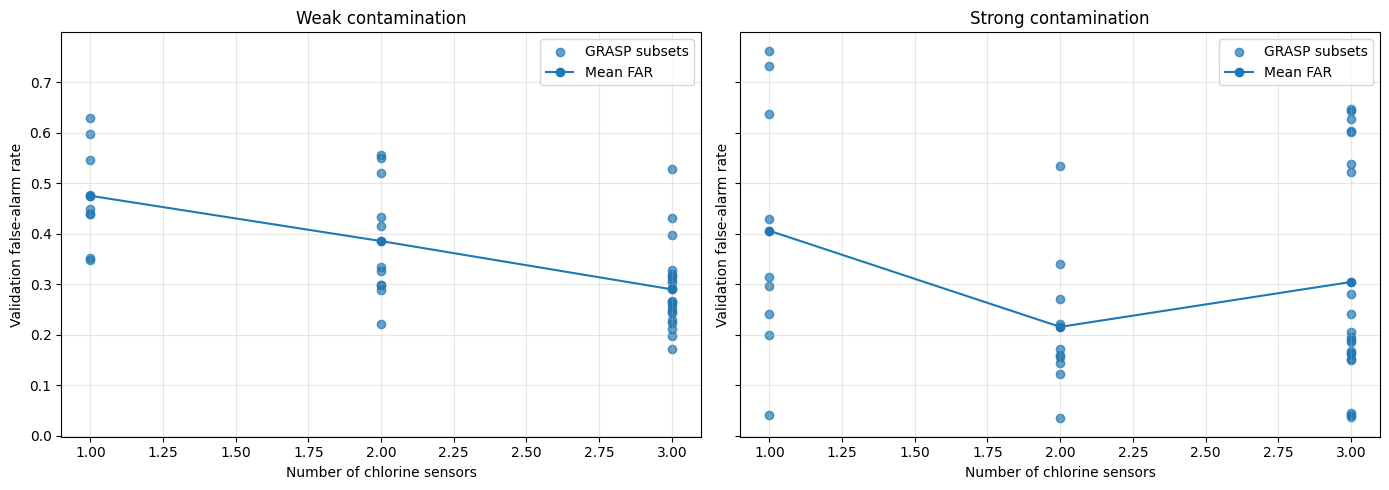


WEAK GRASP result
  selected indices: (1, 2, 4)
  selected nodes: ['11', '12', '21']
  validation BA: 0.7018
  evaluated subsets: 40
  Spearman(sensor count, FAR): -0.6494

STRONG GRASP result
  selected indices: (5, 6, 7)
  selected nodes: ['22', '23', '31']
  validation BA: 0.6848
  evaluated subsets: 40
  Spearman(sensor count, FAR): -0.1308


In [8]:
all_search_records = pd.concat(
    [experiment["records"] for experiment in experiments], ignore_index=True
)
comparison_columns = [
    "dataset", "subset", "nodes", "sensor_count",
    "balanced_accuracy", "recall", "specificity", "false_alarm_rate",
    "precision", "f1_score", "roc_auc", "average_precision",
    "chlorine_rmse", "chlorine_mae", "chlorine_r2",
]
display(all_search_records[comparison_columns].sort_values(
    ["dataset", "sensor_count", "balanced_accuracy"],
    ascending=[True, True, False],
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, experiment in zip(axes, experiments):
    records = experiment["records"]
    axis.scatter(
        records["sensor_count"], records["false_alarm_rate"],
        alpha=0.7, label="GRASP subsets",
    )
    means = records.groupby("sensor_count")["false_alarm_rate"].mean()
    axis.plot(means.index, means.values, "o-", label="Mean FAR")
    axis.set_title(f"{experiment['name'].title()} contamination")
    axis.set_xlabel("Number of chlorine sensors")
    axis.set_ylabel("Validation false-alarm rate")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

for experiment in experiments:
    records = experiment["records"]
    correlation = records["sensor_count"].corr(
        records["false_alarm_rate"], method="spearman"
    )
    result = experiment["search_result"]
    print(f"\n{experiment['name'].upper()} GRASP result")
    print(f"  selected indices: {result.sensor_indices}")
    print(f"  selected nodes: {experiment['selected_nodes']}")
    print(f"  validation BA: {result.metric:.4f}")
    print(f"  evaluated subsets: {result.evaluations}")
    print(f"  Spearman(sensor count, FAR): {correlation:.4f}")


5. Final held-out GRASP evaluation

For each contamination strength, only the GRASP-selected detector is evaluated on the untouched outer test scenarios. No all-sensor reference model is trained or reported.


In [9]:
def plot_metrics(result, figure_title="", chlorine_indices=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    matrix = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix, display_labels=["Normal", "Event"]
    )
    display_matrix.plot(ax=axes[0, 0], colorbar=False, values_format=".2f")
    axes[0, 0].set_title("Confusion matrix")
    plot_roc_curve_event_detection(
        result, title="Event ROC", ax=axes[0, 1]
    )
    plot_chlorine_prediction_quality(
        result,
        chlorine_indices=chlorine_indices,
        title="Chlorine regression",
        ax=axes[1, 0],
    )
    plot_precision_recall_curve(
        result, title="Precision–recall", ax=axes[1, 1]
    )
    if figure_title:
        fig.suptitle(figure_title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    return fig, axes


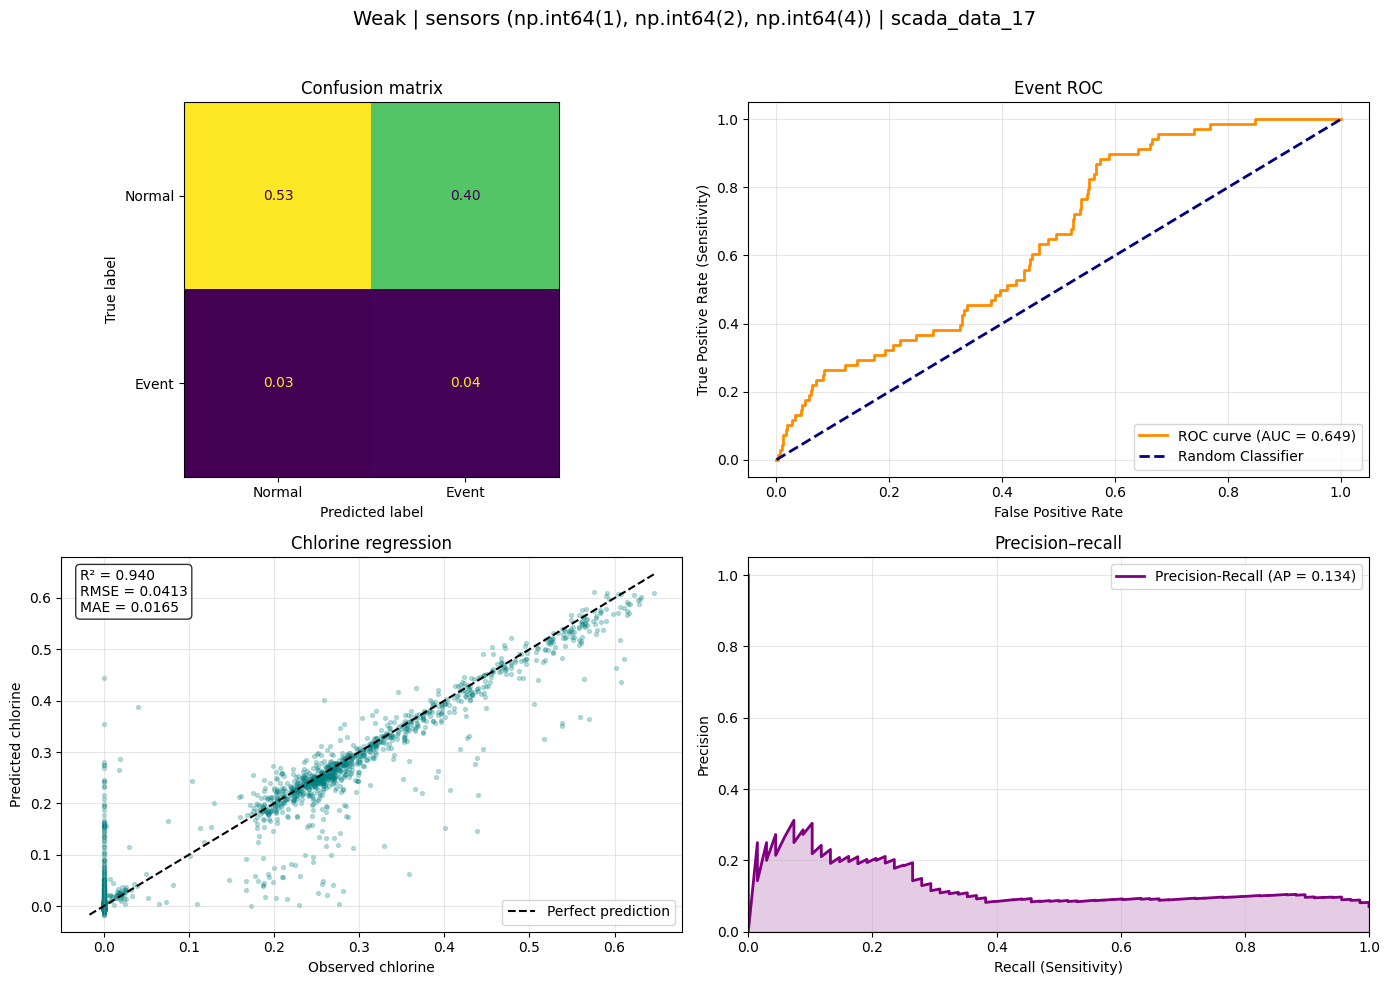

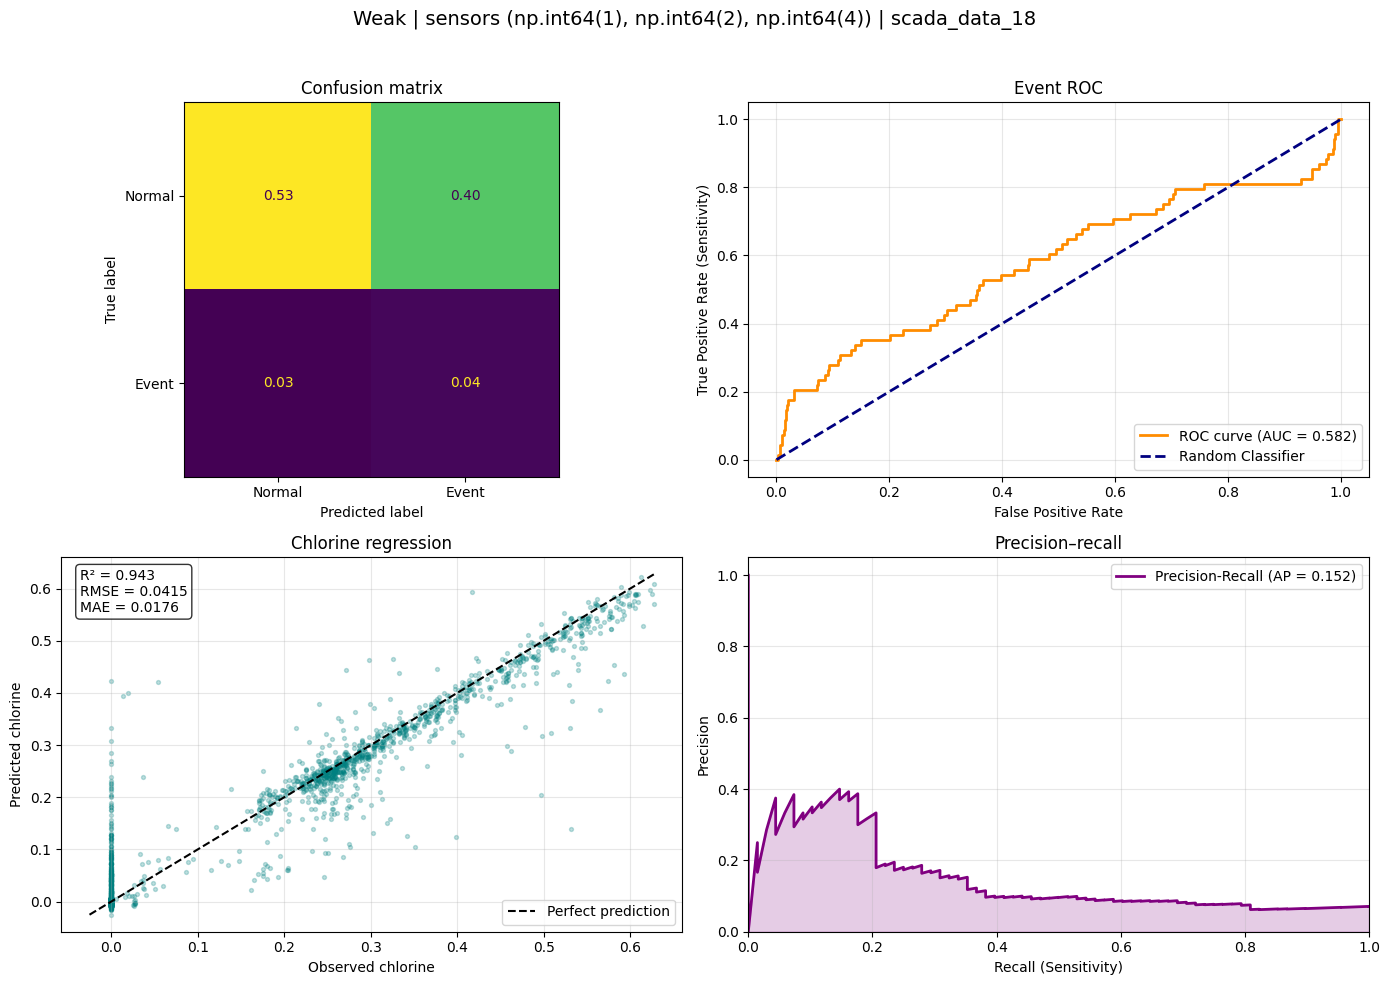

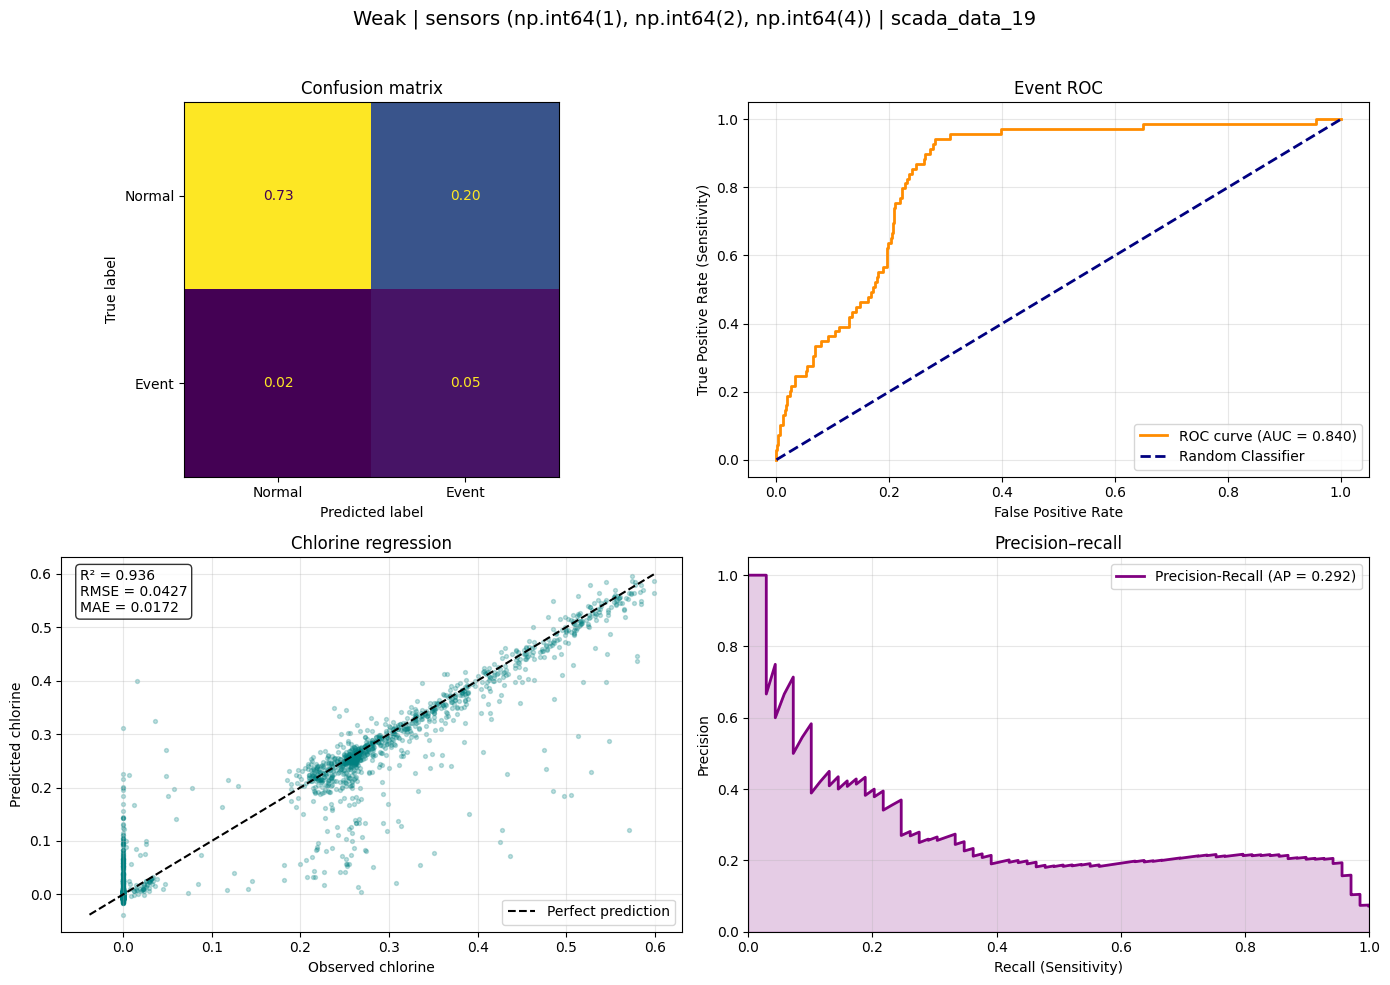

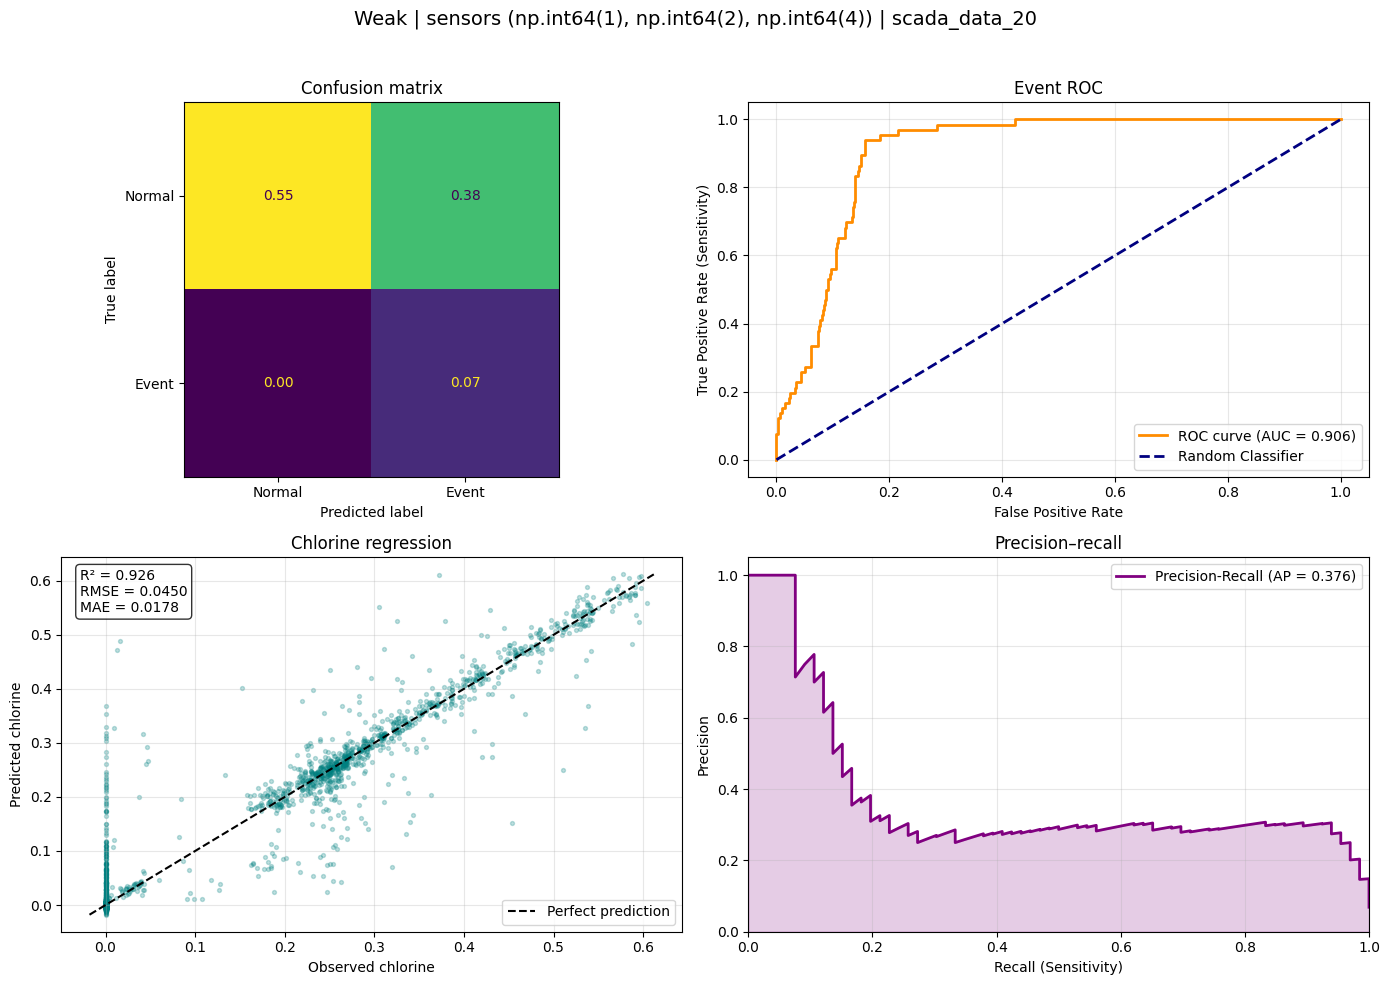

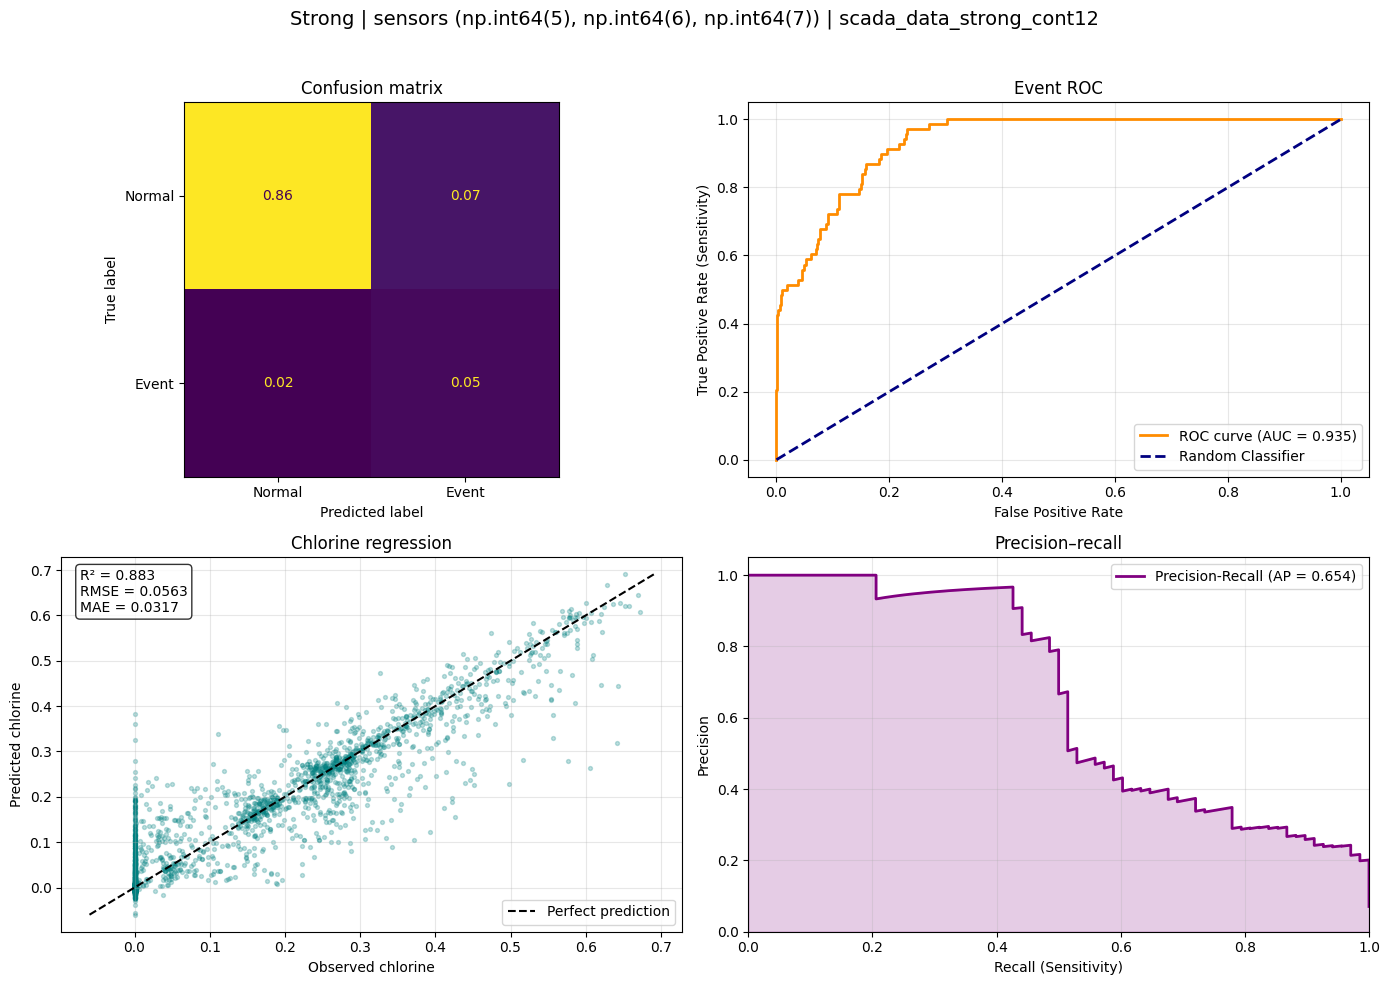

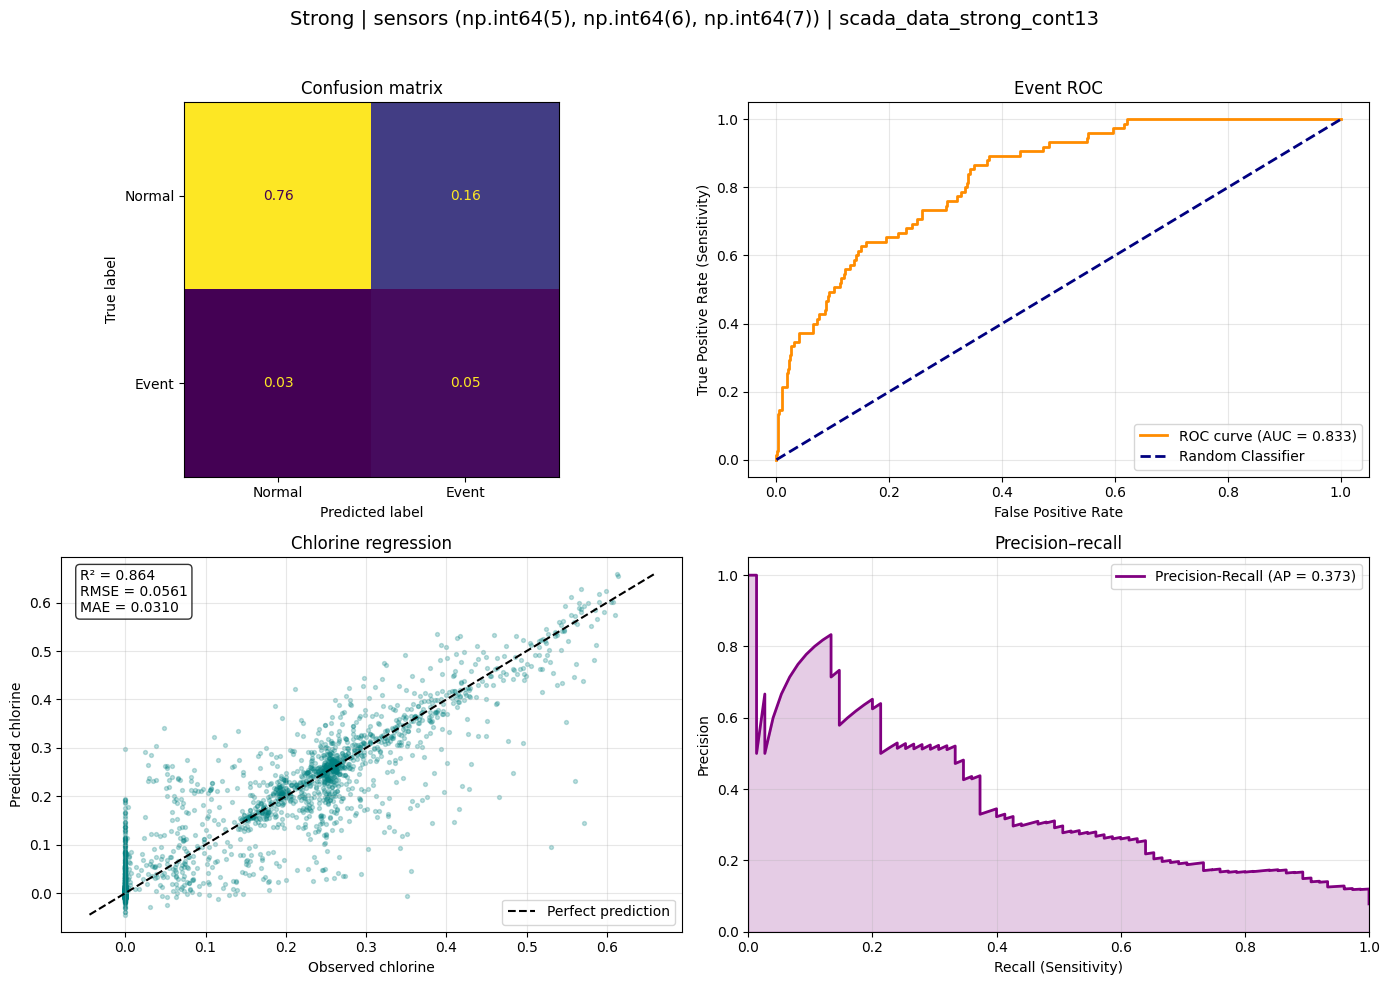

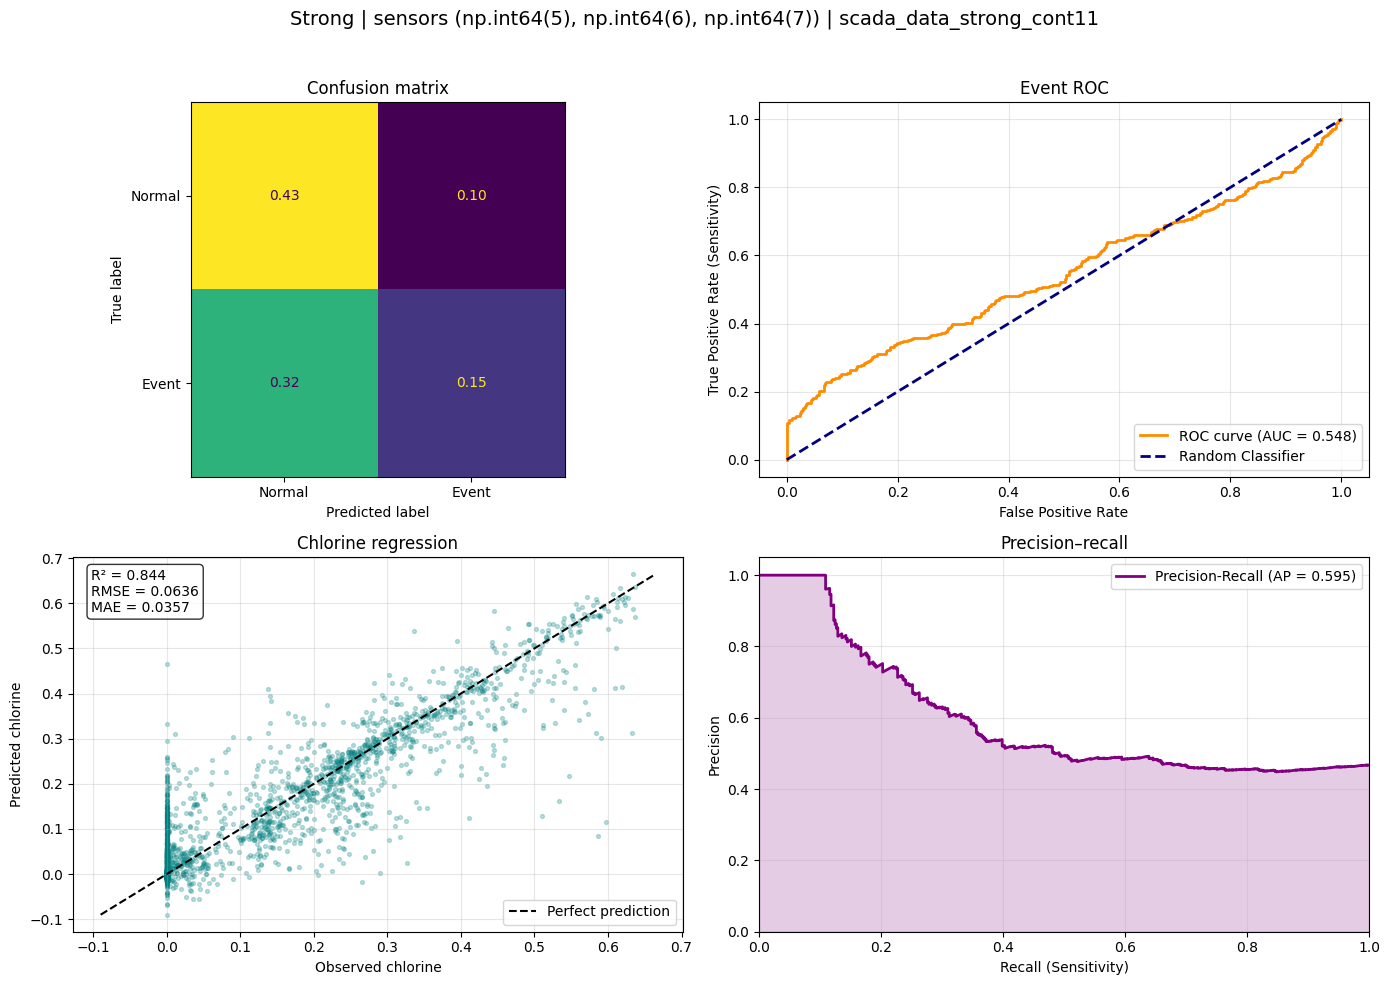

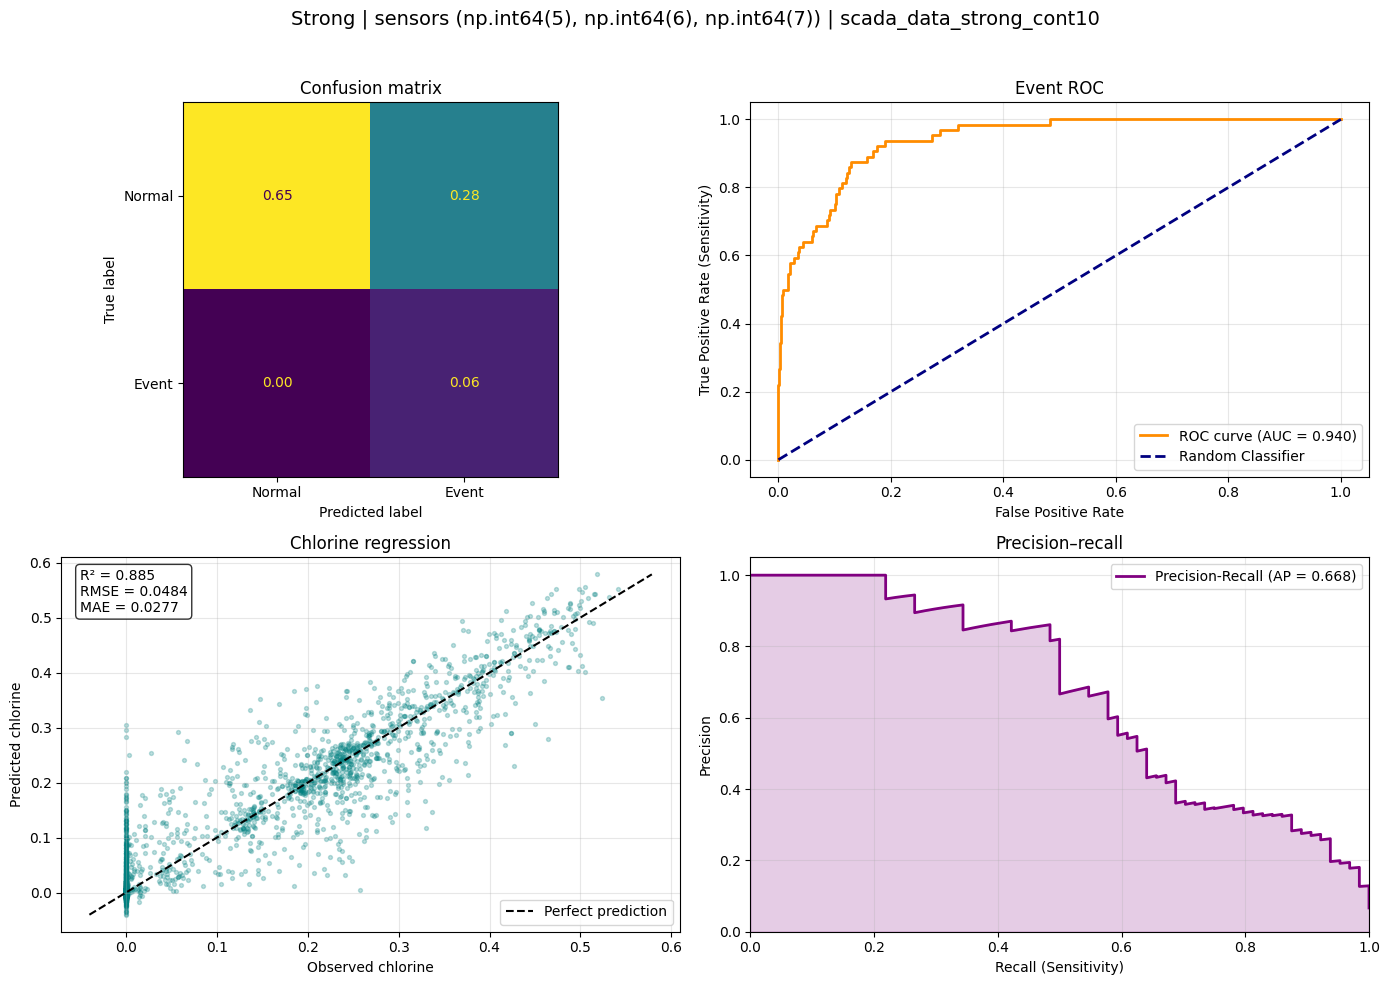

,,sensor_count,sensor_indices,precision,recall,specificity,balanced_accuracy,accuracy,f1_score,roc_auc,average_precision,false_alarm_rate,detection_latency_seconds,chlorine_mae,chlorine_rmse,chlorine_r2
dataset,variant,,,,,,,,,,,,,,,
weak,GRASP selected,3,"(1, 2, 4)",0.125823,0.704797,0.628603,0.666700,0.633975,0.213527,0.732975,0.186648,0.371397,2250.0,0.017260,0.042650,0.936405
strong,GRASP selected,3,"(5, 6, 7)",0.335946,0.457317,0.813990,0.635654,0.753122,0.387347,0.688989,0.446858,0.186010,7200.0,0.031539,0.056374,0.868666


In [10]:
held_out_rows = []
for experiment in experiments:
    detector = experiment["selected_detector"]
    results = [detector.detect(path) for path in experiment["test_paths"]]
    metrics = aggregate_evaluation_summary(results)
    held_out_rows.append({
        "dataset": experiment["name"],
        "variant": "GRASP selected",
        "sensor_count": len(detector.models),
        "sensor_indices": tuple(detector.chlorine_sensor_indices),
        **metrics,
    })
    for path, result in zip(experiment["test_paths"], results):
        plot_metrics(
            result,
            figure_title=(
                f"{experiment['name'].title()} | sensors "
                f"{tuple(detector.chlorine_sensor_indices)} | {path.stem}"
            ),
            chlorine_indices=list(range(result.actual.shape[1])),
        )

held_out_comparison = pd.DataFrame(held_out_rows).set_index(["dataset", "variant"])
display(held_out_comparison)

held_out_comparison[
    ["balanced_accuracy", "recall", "specificity", "false_alarm_rate",
     "precision", "f1_score", "roc_auc", "average_precision",
     "chlorine_rmse", "chlorine_mae", "chlorine_r2"]
].to_csv(project_root / "results" / "ANN" / "grasp_sensor_weak_strong_comparison.csv")


# Comments

When reducing the number of sensors from nine to three the detector in the weak contamination case finds most events (recall ≈ 0.70) but produces many false alarms (FAR ≈ 0.37). Chlorine regression is remains excellent (R² ≈ 0.936, MAE ≈ 0.017), and detection latency remains 2250, like with all sensors.

In the strong contamination case there are fewer false alarms (FAR ≈ 0.186) at the cost of missed events. Chlorine regression still good, but lower than in the weak case(R² ≈ 0.869, MAE ≈ 0.0315) and detection latency is larger (7200 s), with respect to the use of all sensors.

Heterogeneous performance: per-file AUCs range from ≈0.55 to ≈0.94 — the same selected subset can be excellent for some scenarios and poor for others. This suggests signal-to-noise differences.

Chlorine regression is consistently strong across weak and strong settings (R² mostly > 0.84), so failures are mostly classification/thresholding issues rather than regression accuracy.
